In [1]:
from sqlalchemy import create_engine
from sqlalchemy.engine import URL

url = URL.create(
    drivername="postgresql+psycopg2",
    username="postgres",
    password="Dscse@122",
    host="localhost",
    port=5432,
    database="ecommerce_analytics"
)

engine = create_engine(url)

In [2]:
with engine.connect() as conn:
    print("Connected successfully!")

Connected successfully!


In [4]:
import pandas as pd

In [5]:
query = """
SELECT
    DATE_TRUNC(
        'month',
        o.order_purchase_timestamp
    ) AS month,

    ROUND(
        SUM(
            p.payment_value
        ),
        2
    ) AS revenue

FROM orders o

JOIN payments p
    ON o.order_id = p.order_id

GROUP BY month

ORDER BY month;
"""

revenue_df = pd.read_sql(
    query,
    engine
)

In [6]:
revenue_df.to_csv(
    '../data/monthly_revenue.csv',
    index=False
)

In [7]:
revenue_df.head()

,month,revenue
0,2016-09-01,252.24
1,2016-10-01,59090.48
2,2016-12-01,19.62
3,2017-01-01,138488.04
4,2017-02-01,291908.01


In [8]:
revenue_df.shape

(25, 2)

In [9]:
revenue_df.describe()

,month,revenue
count,25,2.500000e+01
mean,2017-09-28 12:28:48,6.403549e+05
min,2016-09-01 00:00:00,1.962000e+01
25%,2017-04-01 00:00:00,2.919080e+05
50%,2017-10-01 00:00:00,6.743963e+05
75%,2018-04-01 00:00:00,1.023880e+06
max,2018-10-01 00:00:00,1.194883e+06
std,NaN,4.316790e+05


In [26]:
revenue_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   month       25 non-null     datetime64[ns]
 1   revenue     25 non-null     float64       
 2   moving_avg  23 non-null     float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 732.0 bytes


In [27]:
revenue_df = revenue_df[
    revenue_df['month'] < '2018-09-01'
]

In [28]:
revenue_df['month'] = pd.to_datetime(
    revenue_df['month']
)

In [30]:
revenue_df.tail()

,month,revenue,moving_avg
18,2018-04-01,1160785.48,1.104300e+06
19,2018-05-01,1153982.15,1.158140e+06
20,2018-06-01,1023880.50,1.112883e+06
21,2018-07-01,1066540.75,1.081468e+06
22,2018-08-01,1022425.32,1.037616e+06


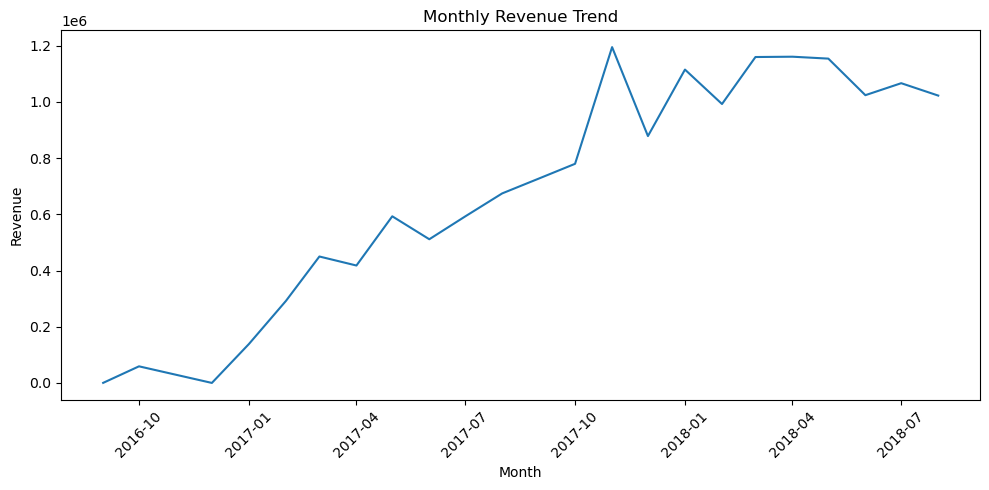

In [29]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

plt.plot(
    revenue_df['month'],
    revenue_df['revenue']
)

plt.title(
    'Monthly Revenue Trend'
)

plt.xlabel(
    'Month'
)

plt.ylabel(
    'Revenue'
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../visualizations/monthly_revenue_trend.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [31]:
revenue_df['moving_avg'] = (
    revenue_df['revenue']
    .rolling(window=3)
    .mean()
)

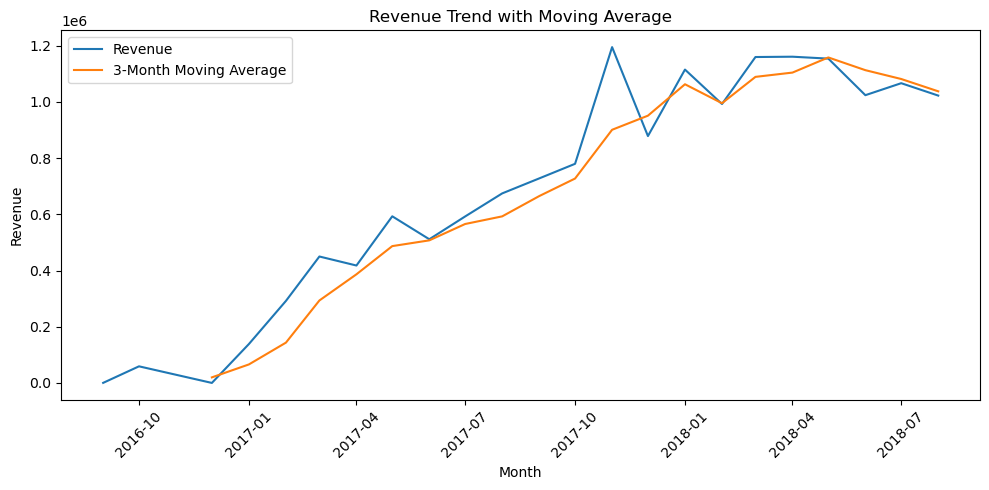

In [32]:
plt.figure(figsize=(10,5))

plt.plot(
    revenue_df['month'],
    revenue_df['revenue'],
    label='Revenue'
)

plt.plot(
    revenue_df['month'],
    revenue_df['moving_avg'],
    label='3-Month Moving Average'
)

plt.legend()

plt.title(
    'Revenue Trend with Moving Average'
)

plt.xlabel(
    'Month'
)

plt.ylabel(
    'Revenue'
)

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    '../visualizations/moving_average_revenue.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [15]:
pip install prophet

   ---------------------------------------- 0.0/12.1 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.1 MB 3.1 MB/s eta 0:00:04
   -- ------------------------------------- 0.8/12.1 MB 2.2 MB/s eta 0:00:06
   ----- ---------------------------------- 1.6/12.1 MB 2.3 MB/s eta 0:00:05
   ------ --------------------------------- 2.1/12.1 MB 2.5 MB/s eta 0:00:04
   -------- ------------------------------- 2.6/12.1 MB 2.5 MB/s eta 0:00:04
   ---------- ----------------------------- 3.1/12.1 MB 2.5 MB/s eta 0:00:04
   ------------ --------------------------- 3.7/12.1 MB 2.4 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.1 MB 2.5 MB/s eta 0:00:04
   ---------------- ----------------------- 5.0/12.1 MB 2.5 MB/s eta 0:00:03
   ----------------- ---------------------- 5.2/12.1 MB 2.5 MB/s eta 0:00:03
   ------------------- -------------------- 6.0/12.1 MB 2.5 MB/s eta 0:00:03
   --------------------- ------------------ 6.6/12.1 MB 2.5 MB/s eta 0:00:03
   ---

In [33]:
prophet_df = revenue_df[
    ['month', 'revenue']
].copy()

prophet_df.columns = [
    'ds',
    'y'
]

In [34]:
from prophet import Prophet

model = Prophet()

model.fit(
    prophet_df
)

15:48:26 - cmdstanpy - INFO - Chain [1] start processing
15:48:26 - cmdstanpy - INFO - Chain [1] done processing


In [35]:
future = model.make_future_dataframe(
    periods=6,
    freq='M'
)

forecast = model.predict(
    future
)

C:\Users\Medha Jha\anaconda3\Lib\site-packages\prophet\forecaster.py:1875: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  dates = pd.date_range(


In [36]:
forecast[
    ['ds','yhat']
].tail(6)


,ds,yhat
23,2018-08-31,1.354944e+06
24,2018-09-30,1.408824e+06
25,2018-10-31,1.464500e+06
26,2018-11-30,1.518380e+06
27,2018-12-31,1.574055e+06
28,2019-01-31,1.629731e+06


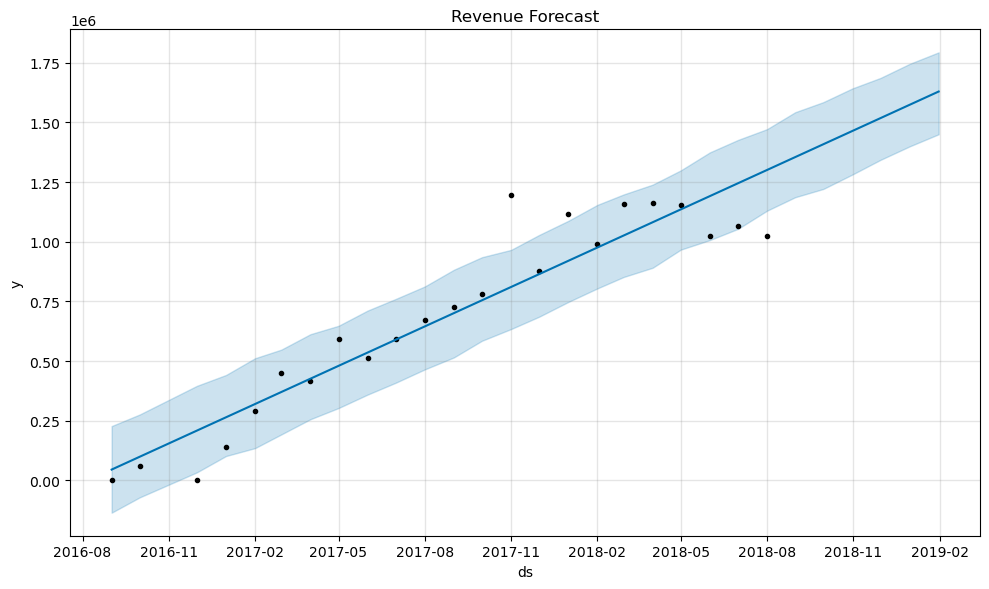

In [37]:
fig = model.plot(
    forecast
)

plt.title(
    'Revenue Forecast'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/revenue_forecast.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

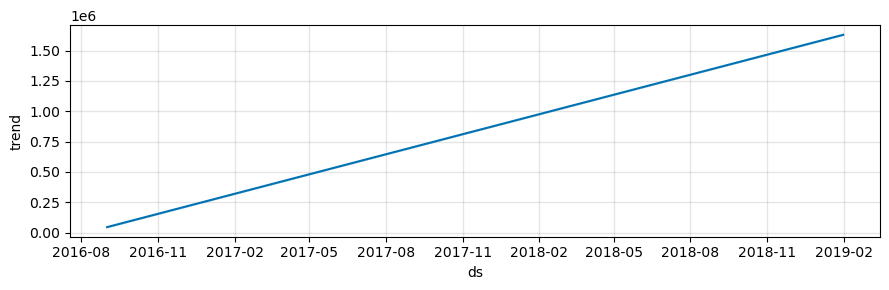

In [38]:
# Seasonability
fig = model.plot_components(
    forecast
)

plt.savefig(
    '../visualizations/forecast_components.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [39]:
# Residual analysis
forecast_train = forecast.iloc[
    :len(prophet_df)
]

residuals = (
    prophet_df['y']
    -
    forecast_train['yhat']
)

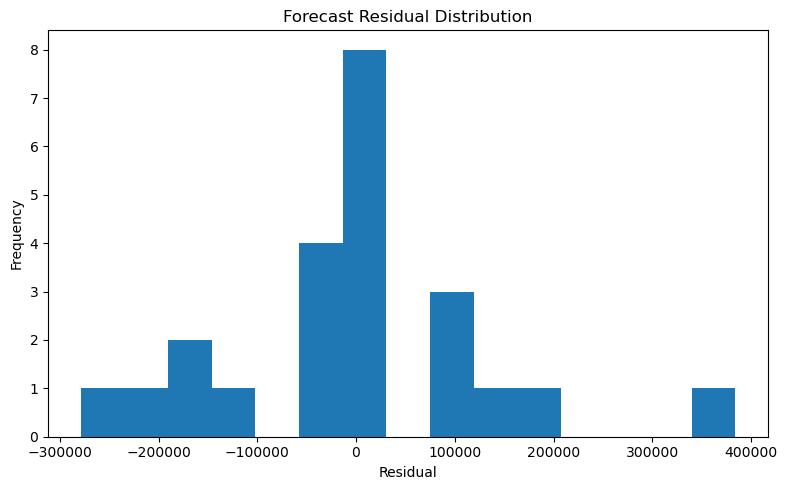

In [40]:
plt.figure(figsize=(8,5))

plt.hist(
    residuals,
    bins=15
)

plt.title(
    'Forecast Residual Distribution'
)

plt.xlabel(
    'Residual'
)

plt.ylabel(
    'Frequency'
)

plt.tight_layout()

plt.savefig(
    '../visualizations/forecast_residuals.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()

In [41]:
forecast.to_csv(
    '../data/revenue_forecast.csv',
    index=False
)


In [42]:
revenue_df.tail()

,month,revenue,moving_avg
18,2018-04-01,1160785.48,1.104300e+06
19,2018-05-01,1153982.15,1.158140e+06
20,2018-06-01,1023880.50,1.112883e+06
21,2018-07-01,1066540.75,1.081468e+06
22,2018-08-01,1022425.32,1.037616e+06
